## Load JAX, KDExpress, and matplotlib for plotting

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", 'cpu') # put 'gpu' here if you have one
import jax.numpy as jnp
import jax

import os,sys
parent_dir = os.getcwd() + '/../src/'
sys.path.append(parent_dir)
from KDExpress import fft_kde3d, scott_bw3d, build_hist_edges, silverman_bw3d

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl

custom_params = {
    # Spine settings - remove top/right, keep bottom/left
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    
    # Tick settings
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.bottom": True,        # Ensure bottom ticks are visible
    "ytick.left": True,          # Ensure left ticks are visible
    
    # Color settings
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.labelcolor": "black",
    
    # Grid settings - explicitly disable
    "axes.grid": False,
    
    # TeX
    "text.usetex": True,
    "mathtext.fontset": "cm",
}

# First, restore default rcParams, then update
plt.rcParams.update(plt.rcParamsDefault)  # Restore defaults
plt.rcParams.update(custom_params)        # Apply your customizations


def scale_fonts_by_figsize(figsize, base_scale=1.0):
    """
    Automatically scale fonts based on figure size.
    
    Parameters
    ----------
    figsize : tuple
        Figure size in inches (width, height)
    base_scale : float
        Base scaling factor
    """
    fig_width = figsize[0]
    
    # Scale factor based on width (reference: 6.4 inches is matplotlib default)
    scale_factor = fig_width / 6.4 * base_scale
    
    font_params = {
        'font.size': 10 * scale_factor,
        'axes.titlesize': 11 * scale_factor,
        'axes.labelsize': 10 * scale_factor,
        'xtick.labelsize': 9 * scale_factor,
        'ytick.labelsize': 9 * scale_factor,
        'legend.fontsize': 8 * scale_factor,
        'figure.titlesize': 11 * scale_factor,
    }
    
    # Update only font parameters
    current_params = plt.rcParams.copy()
    current_params.update(font_params)
    plt.rcParams.update(current_params)

## Useful functions to generate data and plot

In [2]:
def generate_3d_data(key, n_samples=5000):
  keys = jax.random.split(key, 4)
  data = []
  
  data.append(jax.random.multivariate_normal(
      keys[0], 
      mean=jnp.array([1.0, 1.0, 0.5]),
      cov=jnp.array([[0.7, 0.3, 0.1], [0.3, 0.5, 0.2], [0.1, 0.2, 0.6]]),
      shape=(n_samples//3,)
  ))
  data.append(jax.random.multivariate_normal(
      keys[1], 
      mean=jnp.array([-1.0, -1.0, -0.5]),
      cov=jnp.array([[0.5, -0.2, 0.0], [-0.2, 0.8, -0.1], [0.0, -0.1, 0.4]]),
      shape=(n_samples//3,)
  ))
  data.append(jax.random.multivariate_normal(
      keys[2],
      mean=jnp.array([0.0, 1.5, -1.0]),
      cov=jnp.array([[0.3, 0.0, 0.0], [0.0, 0.3, 0.0], [0.0, 0.0, 0.9]]),
      shape=(n_samples//3,)
  ))
  
  return jnp.concatenate(data)

def plot_3d_density(density, grids, title, s = 5, color = None, cmap='plasma'):

  scale_fonts_by_figsize(figsize=(5,4), base_scale=1.5)
  fig = plt.figure(figsize=(5, 4))
  
  # Convert JAX arrays to numpy
  density_jnp = jnp.array(density)
  x = jnp.array(grids[0])
  y = jnp.array(grids[1])
  z = jnp.array(grids[2])
  
  # Create 3D grid
  X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')
  
  # Create plot
  ax = fig.add_subplot(111, projection='3d')
  
  # Threshold for visualization
  threshold = 0.2 * density_jnp.max()
  mask = density_jnp > threshold
  
  # Create the main scatter plot
  sc = ax.scatter(
    X[mask], Y[mask], Z[mask], 
    c=color if color is not None else density_jnp[mask], 
    s=s,
    alpha=1,
    cmap=cmap,
    edgecolors='none'
  )
  
  # Add colorbar in its own axes
  if cmap is not None:
    cax = fig.add_axes([0.9, 0.15, 0.03, 0.7]) 
    cb = fig.colorbar(sc, cax=cax) 
    cb.set_label('PDF')

  ax.set_title(title)
  ax.set_xlabel('x', labelpad=2)
  ax.set_ylabel('y', labelpad=2)
  ax.set_zlabel('z', labelpad=2)
  plt.tight_layout(rect=[0, 0, 0.85, 1])  
  return fig  

## Generate random weighted 3-D data 

/tmp/ipykernel_18700/3558988128.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


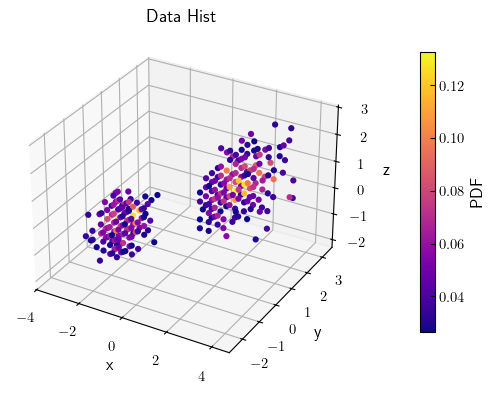

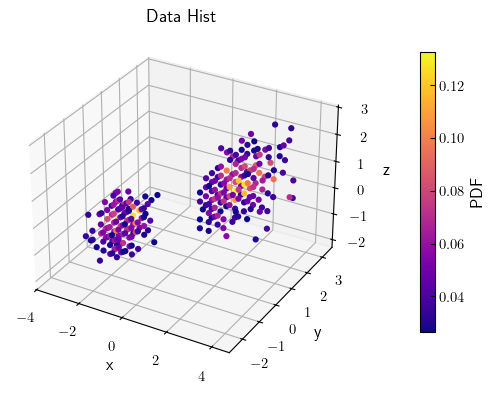

In [3]:
key = jax.random.PRNGKey(42)
data_3d = generate_3d_data(key, n_samples=5000) 
weights = (data_3d**2)[:,0]

# Plot
counts, grids_edges = jnp.histogramdd(data_3d, bins=20, weights=weights, density=True)
grids = [] 
for g in grids_edges:
  grids.append(0.5*(g[1:]+g[:-1]))
plot_3d_density(counts, grids, 'Data Hist', s = 20)

## Define the points where the PDF is evaluated and compute the bin edges around them.

Bin edges shape =  [(501,), (16,), (21,)]


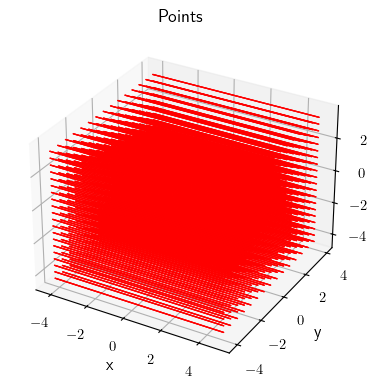

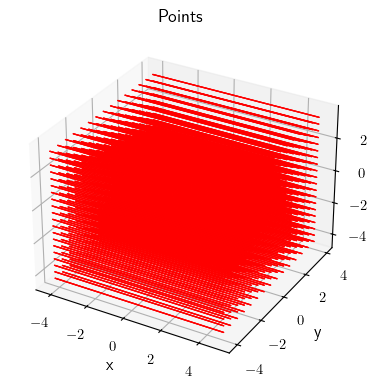

In [4]:
# Create grid and compute bin edges
dims = [500,15,20]
bounds = [(data_3d[:,i].min()-0.5, data_3d[:,i].max()+0.5) for i in range(3)]
grids = [jnp.linspace(b[0], b[1], n) for n,b in zip(dims, bounds)]
points_x = grids[0]
points_y = grids[1]
points_z = grids[2]
px, py, pz = jnp.meshgrid(points_x, points_y, points_z, indexing='ij')
bin_edges = [build_hist_edges(points) for points in [points_x, points_y, points_z]]
print("Bin edges shape = ", [bin_edges[i].shape for i in range(3)])

# Plot the points
bc = [0.5*(be[1:] + be[:-1]) for be in bin_edges]
fake_counts_points = jnp.ones_like(px)
plot_3d_density(fake_counts_points, bc, 'Points', s = 1, color = 'red', cmap=None)

## The KDE is computed by convolving the histogram defined by the previous bin_edges with a Gaussian kernel. The convolution is (efficiently) performed using an FFT.

Estimated bandwidths Silvermann (x, y, z) = [0.28270318 0.35042821 0.26758872]
Estimated bandwidths Scott (x, y, z) = [0.63150831 0.44729033 0.33944253]


/tmp/ipykernel_18700/3558988128.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])
/tmp/ipykernel_18700/3558988128.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


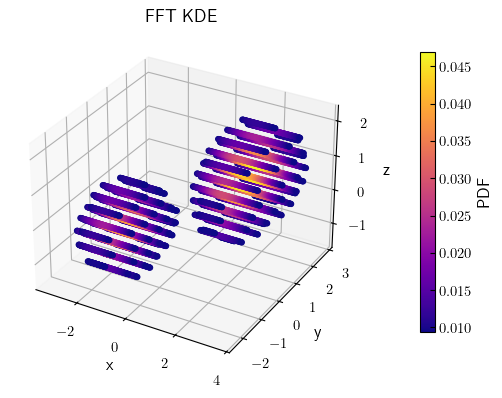

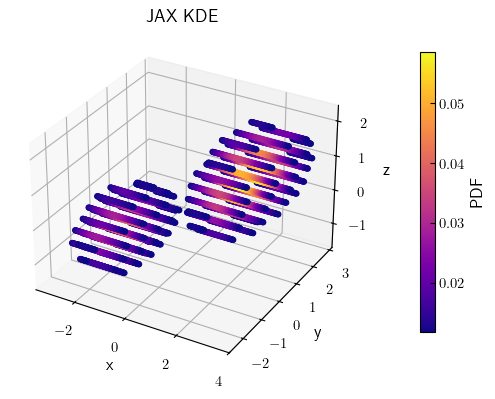

In [5]:
# Calculate optimal bandwidth using Silverman's rule for 3D data
# Returns bandwidth for each dimension [bw_x, bw_y, bw_z]
bw = scott_bw3d(data_3d, weights)
print(f"Estimated bandwidths Silvermann (x, y, z) = {silverman_bw3d(data_3d)}")
print(f"Estimated bandwidths Scott (x, y, z) = {bw}")

# Compute 3D KDE using FFT-based method
pdf_est_fft = fft_kde3d(
  points_x, 
  points_y, 
  points_z,
  data_3d,
  weights=weights,
  bin_edges=bin_edges,  # Optional reuse of bin edges
  bw=bw
)

def weighted_std(data, weights):
  mean = jnp.average(data, weights=weights)
  variance = jnp.average((data - mean)**2, weights=weights)
  return jnp.sqrt(variance)

def jax_scipy_kde_3d(x_grid, y_grid, z_grid, data, weights=None, bw_method=None):
  kde = jax.scipy.stats.gaussian_kde(
    data.T,
    bw_method=bw_method,
    weights=weights
  )
  X, Y, Z = jnp.meshgrid(
    x_grid, 
    y_grid, 
    z_grid,
    indexing='ij'
  )
  positions = jnp.vstack([X.ravel(), Y.ravel(), Z.ravel()])
  density = kde(positions).reshape(X.shape)    
  return density

# Note: JAX KDE assume a unique bw, while in our FFT based computation the BW is different for each axis.
pdf_est_jax = jax_scipy_kde_3d(
  points_x,
  points_y, 
  points_z,
  data_3d,
  weights=weights,
  #bw_method =  jnp.mean(bw / jax.vmap(weighted_std, in_axes=(1,None))(data_3d, weights))   
)

# Plot
fig_fft = plot_3d_density(pdf_est_fft, (points_x, points_y, points_z), 'FFT KDE', s = 20, color = None, cmap='plasma')
fig_fft.savefig('kde_3d_fft.pdf')
fig_jax = plot_3d_density(pdf_est_jax, (points_x, points_y, points_z), 'JAX KDE', s = 20, color = None, cmap='plasma')
fig_jax.savefig('kde_3d_jax.pdf')
plt.show()

In [6]:
%timeit  jax_scipy_kde_3d(points_x, points_y, points_z, data_3d, weights=weights).block_until_ready()

1.92 s ± 299 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
%timeit  fft_kde3d(points_x, points_y, points_z, data_3d, weights=weights).block_until_ready()

9.49 ms ± 1.53 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
